In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the data

In [2]:
df_products= pd.read_csv('../data/products.csv')
df_order_items= pd.read_csv('../data/order_items.csv', low_memory=False)

### Merged file products.csv and order_items.csv through product_id column

In [3]:
df_merged= pd.merge(df_products, df_order_items, on='product_id', how='left')

In [4]:
print("Cột trong order_items:", df_order_items.columns.tolist())
print("Cột sau khi merged:", df_merged.columns.tolist())

Cột trong order_items: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
Cột sau khi merged: ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs', 'order_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


In [5]:
df_merged.head()

,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451.0,5.0,11183.67,0.0,NaN,NaN
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898.0,8.0,10918.75,0.0,NaN,NaN
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268.0,6.0,11184.55,0.0,NaN,NaN
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907.0,2.0,11104.72,0.0,NaN,NaN
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911.0,6.0,11143.16,0.0,NaN,NaN


In [6]:
df_promos = pd.read_csv('../data/promotions.csv')
df_final = df_merged.merge(df_promos, on='promo_id', how='left')
display(df_final.head())

,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_id_2,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_orders = pd.read_csv('../data/orders.csv', parse_dates=['order_date'])
df_master = df_final.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')

df_master = df_master.rename(columns={'order_date': 'Date'})
print("Kích thước bảng Master:", df_master.shape)
display(df_master.head())

Kích thước bảng Master: (715483, 24)


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value,Date
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-07
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-13
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-13
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-17
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-24


In [8]:
check_promo = df_final[df_final['promo_name'].notna()]
print(f"Tổng số dòng có thông tin khuyến mãi: {len(check_promo)}")
display(check_promo.head())

Tổng số dòng có thông tin khuyến mãi: 276316


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_id_2,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
14,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,259871.0,1.0,...,NaN,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,NaN,all_channels,1.0,100000.0
15,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268094.0,6.0,...,NaN,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,NaN,all_channels,1.0,100000.0
16,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268430.0,8.0,...,NaN,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,NaN,all_channels,1.0,100000.0
26,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,299601.0,3.0,...,NaN,Mid-Year Sale 2015,percentage,18.0,2015-06-23,2015-07-22,NaN,social_media,0.0,0.0
27,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,523256.0,7.0,...,NaN,Urban Blowout 2017,fixed,50.0,2017-07-30,2017-09-02,Streetwear,online,0.0,150000.0


### Fill missing values by None with 'category' and 0 with 'int/float'

In [9]:
cols_to_fix_str = ['promo_id', 'promo_name', 'promo_type', 'promo_channel', 'promo_id_2', 'applicable_category', 'start_date', 'end_date']
df_master[cols_to_fix_str] = df_master[cols_to_fix_str].fillna('None')

df_master['discount_value'] = df_master['discount_value'].fillna(0)
df_master['min_order_value'] = df_master['min_order_value'].fillna(0)
print("Số dòng còn lại:", len(df_master))
print("Số giá trị thiếu còn lại:", df_master.isnull().sum().sum())

Số dòng còn lại: 715483
Số giá trị thiếu còn lại: 443237


In [ ]:
print("Tổng số sản phẩm sau khi merge:", len(df_master))
print("Số lượng đơn hàng có Date:", df_master['Date'].notnull().sum())
print(f"=> Phát hiện: {len(df_master) - df_master['Date'].notnull().sum()} sản phẩm chưa bao giờ được bán.")

Tổng số sản phẩm sau khi merge: 715483
Số lượng đơn hàng có Date: 714669
=> Phát hiện: 814 sản phẩm chưa bao giờ được bán.


### Insight: Có 814 "sản phẩm ma" (Deadstock). Chúng ta cần loại bỏ chúng để dữ liệu dự báo không bị nhiễu.

In [11]:
df_master = df_master.dropna(subset=['Date']).reset_index(drop=True)
print("Kích thước bảng thực tế:", df_master.shape)

Kích thước bảng thực tế: (714669, 24)


In [12]:
df_final['discount_value'].value_counts()

discount_value
20.0    71799
12.0    71591
18.0    57417
10.0    45654
50.0    20950
15.0     8905
Name: count, dtype: int64

In [13]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   product_id           714669 non-null  int64         
 1   product_name         714669 non-null  object        
 2   category             714669 non-null  object        
 3   segment              714669 non-null  object        
 4   size                 714669 non-null  object        
 5   color                714669 non-null  object        
 6   price                714669 non-null  float64       
 7   cogs                 714669 non-null  float64       
 8   order_id             714669 non-null  float64       
 9   quantity             714669 non-null  float64       
 10  unit_price           714669 non-null  float64       
 11  discount_amount      714669 non-null  float64       
 12  promo_id             714669 non-null  object        
 13  promo_id_2    

### Check if any columns are missing data.

In [14]:
missing_data = df_master.isnull().sum()
print(missing_data[missing_data > 0])

stackable_flag    438353
dtype: int64


In [15]:
if 'stackable_flag' in df_master.columns:
    df_master['stackable_flag'] = df_master['stackable_flag'].fillna(0)

In [16]:
missing_data = df_master.isnull().sum()
print(missing_data[missing_data > 0])

Series([], dtype: int64)


# 2. EDA

In [17]:
df_master['Revenue_line'] = df_master['quantity'] * df_master['unit_price']
df_master['COGS_line'] = df_master['quantity'] * df_master['cogs']
df_master['Profit_line'] = df_master['Revenue_line'] - df_master['COGS_line']

display(df_master[['product_name', 'quantity', 'unit_price', 'cogs', 'Revenue_line', 'Profit_line']].head())

,product_name,quantity,unit_price,cogs,Revenue_line,Profit_line
0,SaigonFlex UC-01,5.0,11183.67,9704.842875,55918.35,7394.135625
1,SaigonFlex UC-01,8.0,10918.75,9704.842875,87350.00,9711.257000
2,SaigonFlex UC-01,6.0,11184.55,9704.842875,67107.30,8878.242750
3,SaigonFlex UC-01,2.0,11104.72,9704.842875,22209.44,2799.754250
4,SaigonFlex UC-01,6.0,11143.16,9704.842875,66858.96,8629.902750


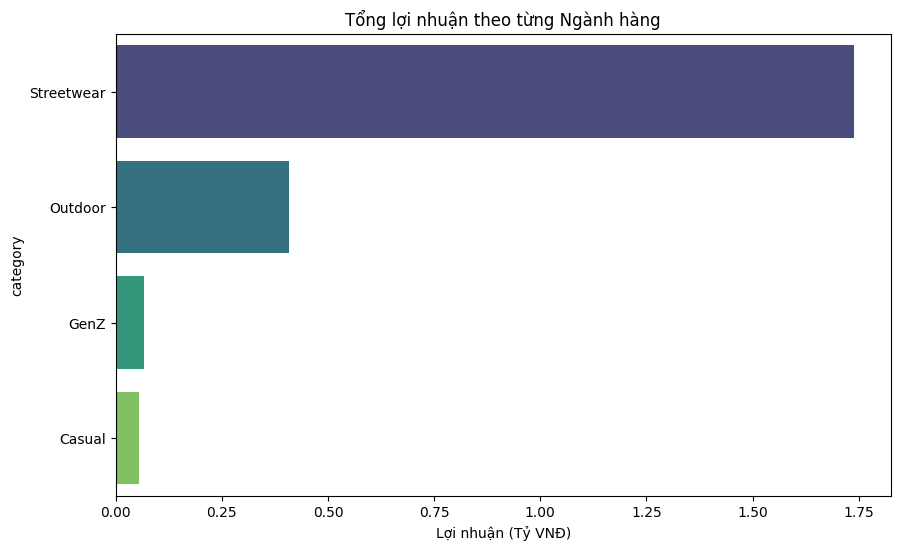

In [18]:
cat_data = df_master.groupby('category')[['Revenue_line', 'Profit_line']].sum().reset_index()
cat_data = cat_data.sort_values('Profit_line', ascending=False)
cat_data['Profit_Billion'] = cat_data['Profit_line'] / 1e9

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_data, x='Profit_Billion', y='category', hue='category', palette='viridis', legend=False)
plt.title('Tổng lợi nhuận theo từng Ngành hàng')
plt.xlabel('Lợi nhuận (Tỷ VNĐ)')
plt.show()

### As illustrated in the bar chart, the Streetwear category accounts for the lion's share of total profit, reaching approximately 1.75 billion VND. My team suggested focusing the marketing budget on this segment to optimize cash flow.

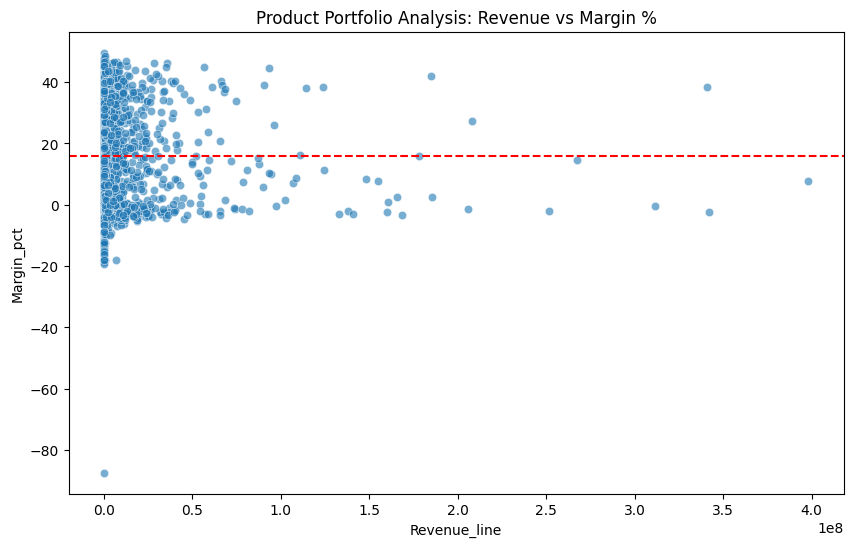

In [19]:
prod_analysis = df_master.groupby('product_name').agg({
    'Revenue_line': 'sum',
    'Profit_line': 'sum'
}).reset_index()
prod_analysis['Margin_pct'] = (prod_analysis['Profit_line'] / prod_analysis['Revenue_line']) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=prod_analysis, x='Revenue_line', y='Margin_pct', alpha=0.6)
plt.axhline(prod_analysis['Margin_pct'].mean(), color='red', linestyle='--', label='Average Margin')
plt.title('Product Portfolio Analysis: Revenue vs Margin %')
plt.show()

### The scatter plot reveals a significant disparity in product performance. While the majority of items are clustered in the low-revenue zone, a few outliers stand out as high-performers with profit margins exceeding the mean of approximately 16%. Notably, there is a concerning anomaly in the bottom-left quadrant exhibiting a negative margin of nearly -80%, which warrants further investigation into potential pricing errors or aggressive discounting strategies.

In [20]:
outlier = prod_analysis.sort_values('Margin_pct').head(1)
display(outlier)

,product_name,Revenue_line,Profit_line,Margin_pct
1325,VietMode UR-02,15906.06,-13892.058,-87.338147


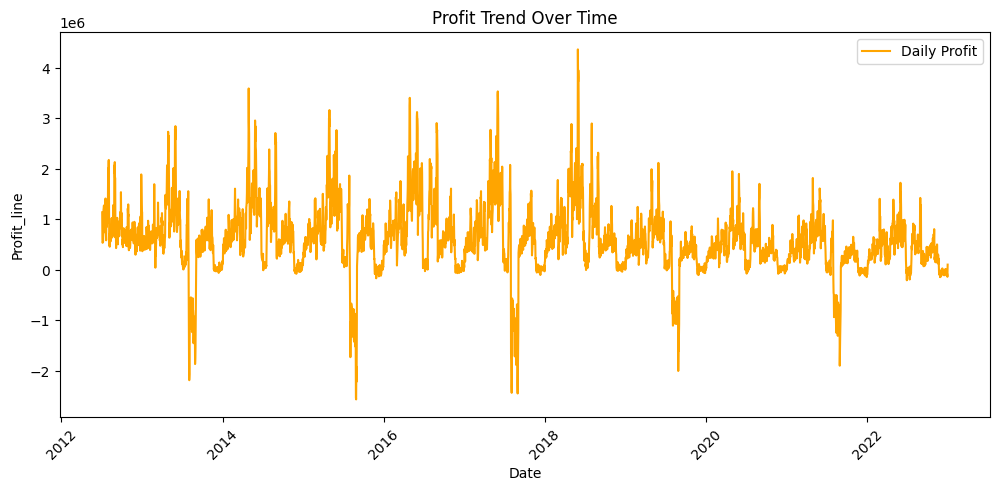

In [21]:
daily_trend = df_master.groupby('Date')[['Revenue_line', 'Profit_line']].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_trend, x='Date', y='Profit_line', color='orange', label='Daily Profit')
plt.title('Profit Trend Over Time')
plt.xticks(rotation=45)
plt.show()

### The line chart illustrates the **daily profit fluctuations** over a decade. It is palpably evident that the business experiences **extreme volatility**, characterized by frequent peaks and significant "dips" where profit plummets into negative territory. 

* **Seasonality:** The recurring spikes suggest a strong seasonal pattern, possibly linked to annual shopping festivals or holiday seasons.
* **Anomalies:** Several "deep dips" (negative profit) are observed periodically. These could be attributed to **aggressive loss-leader strategies** or major clearance sales aimed at inventory turnover rather than immediate margin.
* **Overall Trend:** Despite the volatility, the business maintains a relatively stable baseline, though a slight saturation is visible in the latter years (2020-2022).

# 3.Feature Engineering

In [22]:
df_master['day_of_week'] = df_master['Date'].dt.dayofweek
df_master['month'] = df_master['Date'].dt.month
df_master['is_weekend'] = df_master['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [23]:
df_master['is_promoted']= df_master['promo_id'].apply(lambda x: 0 if x == 'None' else 1)
df_master['discount_rate'] = (df_master['price'] - df_master['unit_price']) / df_master['price']
df_master['discount_rate'] = df_master['discount_rate'].fillna(0)

In [24]:
df_daily = df_master.groupby('Date').agg({
    'Revenue_line': 'sum',
    'is_promoted': 'max',     
    'day_of_week': 'first',
    'is_weekend': 'first'
}).reset_index()
df_daily['revenue_lag_1'] = df_daily['Revenue_line'].shift(1)
df_daily['revenue_lag_7'] = df_daily['Revenue_line'].shift(7)
df_daily = df_daily.fillna(0)

### Feature Engineering Strategy:
* To surpass the established baseline, we implemented a robust feature engineering pipeline. Beyond basic temporal variables like day_of_week and is_weekend, we introduced Lag Features (Lag 1​ and Lag 7) to capture the autocorrelation inherent in sales data. Furthermore, by encoding promotion status, the model can now distinguish between natural demand and artificially inflated sales driven by marketing campaigns.

# 4. Machine Learning

In [ ]:
# One-Hot Encoding cho Category & Segment
df_encoded = pd.get_dummies(df_master, columns=['category', 'segment'], prefix=['cat', 'seg'])

# Lấy danh sách các cột vừa mới tạo ra từ One-Hot
encoded_cols = [col for col in df_encoded.columns if col.startswith(('cat_', 'seg_'))]

special_days = [
    '01-01', '02-14',
    '04-30', '05-01',
    '09-09', '11-11', '12-12',
    '31-12', '12-24', '12-25'
]
def get_special_event(date):
    return 1 if date.strftime('%m-%d') in special_days else 0
# Daily Aggregation: Nén dữ liệu về dạng Ngày
df_encoded['is_special'] = df_encoded['Date'].apply(get_special_event)
# Với các cột One-Hot, chúng ta dùng 'sum' để biết ngày đó bán được bao nhiêu món thuộc loại đó
agg_logic = {
    'Revenue_line': 'sum',
    'Profit_line': 'sum',
    'quantity': 'sum',
    'is_promoted': 'max',  
    'day_of_week': 'first',
    'month': 'first',
    'is_weekend': 'first',
    'is_special': 'max'
}
# Thêm các cột encoded vào logic tính tổng
for col in encoded_cols:
    agg_logic[col] = 'sum'
df_daily = df_encoded.groupby('Date').agg(agg_logic).reset_index()
# Lag Features
# Model sẽ nhìn vào kết quả của 1 ngày và 7 ngày trước đó để dự báo
df_daily['rev_lag_1'] = df_daily['Revenue_line'].shift(1)
df_daily['rev_lag_7'] = df_daily['Revenue_line'].shift(7)

# 4. Xử lý giá trị trống do lệnh shift tạo ra
df_daily = df_daily.fillna(0)

# Đổi tên cho đúng format
df_daily = df_daily.rename(columns={'Revenue_line': 'Revenue', 'Profit_line': 'Profit'})

print("Kích thước bảng Daily:", df_daily.shape)
display(df_daily.head())

Kích thước bảng Daily: (3833, 23)


,Date,Revenue,Profit,quantity,is_promoted,day_of_week,month,is_weekend,is_special,cat_Casual,...,seg_Activewear,seg_All-weather,seg_Balanced,seg_Everyday,seg_Performance,seg_Premium,seg_Standard,seg_Trendy,rev_lag_1,rev_lag_7
0,2012-07-04,5123547.94,1.140557e+06,777.0,0,2,7,0,0,5,...,38,5,34,70,13,3,4,7,0.00,0.0
1,2012-07-05,2751773.45,6.011932e+05,428.0,0,3,7,0,0,1,...,20,1,18,44,9,3,1,7,5123547.94,0.0
2,2012-07-06,3054029.42,5.363966e+05,441.0,0,4,7,0,0,3,...,21,3,17,36,16,0,1,5,2751773.45,0.0
3,2012-07-07,2667930.94,5.596843e+05,364.0,0,5,7,1,0,1,...,14,1,21,30,7,0,1,1,3054029.42,0.0
4,2012-07-08,2360851.90,5.522291e+05,394.0,0,6,7,1,0,0,...,21,0,13,39,12,0,3,6,2667930.94,0.0


In [ ]:
from xgboost import XGBRegressor

df_daily['COGS'] = df_daily['Revenue'] - df_daily['Profit']
# Xác định danh sách Feature
features = [col for col in df_daily.columns if col not in ['Date', 'Revenue', 'Profit', 'COGS']]
print(features)
model_rev = XGBRegressor(
    n_estimators=300,     
    learning_rate=0.03,  
    max_depth=4,          
    subsample=0.8,
    random_state=42
)
model_rev.fit(df_daily[features], df_daily['Revenue'])

model_cogs= XGBRegressor(
    n_estimators=300,     
    learning_rate=0.03,   
    max_depth=4,          
    subsample=0.8,
    random_state=42
)
model_cogs.fit(df_daily[features], df_daily['COGS'])

print("✅ Đã huấn luyện xong bộ đôi 'não bộ' cho Model!")

['quantity', 'is_promoted', 'day_of_week', 'month', 'is_weekend', 'is_special', 'cat_Casual', 'cat_GenZ', 'cat_Outdoor', 'cat_Streetwear', 'seg_Activewear', 'seg_All-weather', 'seg_Balanced', 'seg_Everyday', 'seg_Performance', 'seg_Premium', 'seg_Standard', 'seg_Trendy', 'rev_lag_1', 'rev_lag_7']
✅ Đã huấn luyện xong bộ đôi 'não bộ' cho Model!


In [ ]:
# Xác định các nhóm đặc trưng
time_features = ['month', 'day', 'day_of_week', 'is_weekend']
map_features = [f for f in features if f not in time_features]

# Tạo bảng tra cứu từ 2022 theo baseline
seasonal_lookup = df_daily[df_daily['Date'].dt.year == 2022].copy()
seasonal_lookup['month'] = seasonal_lookup['Date'].dt.month
seasonal_lookup['day'] = seasonal_lookup['Date'].dt.day

cols_to_get = map_features + ['Revenue', 'COGS']
seasonal_lookup = seasonal_lookup.groupby(['month', 'day'])[cols_to_get].mean().reset_index()
seasonal_lookup = seasonal_lookup.rename(columns={'Revenue': 'hist_revenue', 'COGS': 'hist_cogs'})

# Tạo khung X_test cho 548 ngày
future_dates = pd.date_range(start='2023-01-01', end='2024-07-01', freq='D')
X_test = pd.DataFrame({'Date': future_dates})
X_test['month'] = X_test['Date'].dt.month
X_test['day'] = X_test['Date'].dt.day
X_test['day_of_week'] = X_test['Date'].dt.dayofweek
X_test['is_weekend'] = X_test['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
# Trong cell dự báo (inference)
X_test['is_special'] = X_test['Date'].apply(get_special_event)

# Merge
X_test = X_test.merge(seasonal_lookup, on=['month', 'day'], how='left')

# Bổ sung các cột thiếu và điền trống
for col in features:
    if col not in X_test.columns:
        X_test[col] = df_daily[col].mean()
X_test = X_test.ffill().fillna(0)

# Dự báo
pred_rev = model_rev.predict(X_test[features])
pred_cogs = model_cogs.predict(X_test[features])

# BLENDING
growth_factor = 1.05
blend_revenue = (X_test['hist_revenue'] * growth_factor * 0.8) + (pred_rev * 0.2)
blend_cogs = (X_test['hist_cogs'] * growth_factor * 0.8) + (pred_cogs * 0.2)

submission_final = pd.DataFrame({
    'Date': X_test['Date'].dt.strftime('%Y-%m-%d'),
    'Revenue': blend_revenue,
    'COGS': blend_cogs
})

submission_final.to_csv('submission_khang_blended_v2.csv', index=False)
print(f"File 'submission_khang_blended_v2.csv' đã sẵn sàng nộp.")

File 'submission_khang_blended_v2.csv' đã sẵn sàng nộp.
